# Tutorial 2 · Synapses and projections

**What you'll learn.** How to wire one population of neurons to another with a
single `brainpy.state.AlignPostProj`, and how to watch the postsynaptic
conductance and membrane potential evolve as presynaptic spikes arrive.

**Who it's for.** Readers who have done :doc:`01-first-neuron`. (Audience:
simulation and training.)

A **projection** bundles the four ingredients that define how one group talks to
another:

- **comm** — the connection (a weight matrix / sparse connectivity, e.g.
  `EventFixedProb`);
- **syn** — the synapse dynamics (here an exponential conductance, `Expon`);
- **out** — how the synaptic variable enters the target (conductance-based
  `COBA` or current-based `CUBA`);
- **post** — the target population.

`AlignPostProj` keeps the synaptic state aligned to the *postsynaptic* neurons,
so memory scales as `O(N_post)` rather than with the number of synapses. The
*why* is the keystone concept chapter :doc:`/concepts/alignpre-alignpost`; here
we just use it.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A two-population network

The presynaptic population is driven by an external current and spikes; those
spikes feed the projection, which charges an exponential conductance on the
postsynaptic population. Note the `.desc(...)` describers for `syn` and `out`:
the projection builds those sub-modules itself, sized to the target.

In [2]:
class TwoPop(brainstate.nn.Module):
    def __init__(self, n_pre=20, n_post=10):
        super().__init__()
        self.n_pre = n_pre
        self.n_post = n_post
        self.pre = brainpy.state.LIFRef(
            n_pre, tau=20. * u.ms, tau_ref=5. * u.ms,
            V_rest=-60. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV,
        )
        self.post = brainpy.state.LIFRef(
            n_post, tau=20. * u.ms, tau_ref=5. * u.ms,
            V_rest=-60. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV,
        )
        # one projection: pre -> post
        self.proj = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(
                n_pre, n_post, conn_num=0.5, conn_weight=0.5 * u.mS),
            syn=brainpy.state.Expon.desc(n_post, tau=5. * u.ms),
            out=brainpy.state.COBA.desc(E=0. * u.mV),
            post=self.post,
        )

    def update(self, t, drive):
        with brainstate.environ.context(t=t):
            pre_spikes = self.pre.get_spike() != 0.
            self.proj(pre_spikes)                  # route spikes through the synapse
            self.pre(drive)                        # advance presynaptic neurons
            self.post(0. * u.mA)                   # post driven only by the synapse
            return (self.post.V.value,
                    self.proj.syn.g.value,         # postsynaptic conductance
                    pre_spikes)

## Run it and record

We record the postsynaptic membrane potential, the synaptic conductance `g`
(reachable as `proj.syn.g`), and the presynaptic spikes.

In [3]:
with brainstate.environ.context(dt=0.1 * u.ms):
    net = TwoPop()
    brainstate.nn.init_all_states(net)

    times = u.math.arange(0. * u.ms, 200. * u.ms, brainstate.environ.get_dt())
    post_V, syn_g, pre_spk = brainstate.transform.for_loop(
        lambda t: net.update(t, 30. * u.mA), times)

print('postsynaptic V:', post_V.shape)
print('synaptic conductance g:', syn_g.shape, '(unit:', u.get_unit(syn_g), ')')

postsynaptic V: (2000, 10)
synaptic conductance g: (2000, 10) (unit: mS )


## Visualize the synaptic interaction

Top: presynaptic spike raster. Middle: the postsynaptic conductance summed over
the population — each presynaptic spike kicks it up, then it decays
exponentially with the synaptic time constant. Bottom: the postsynaptic membrane
potential responding to that conductance.

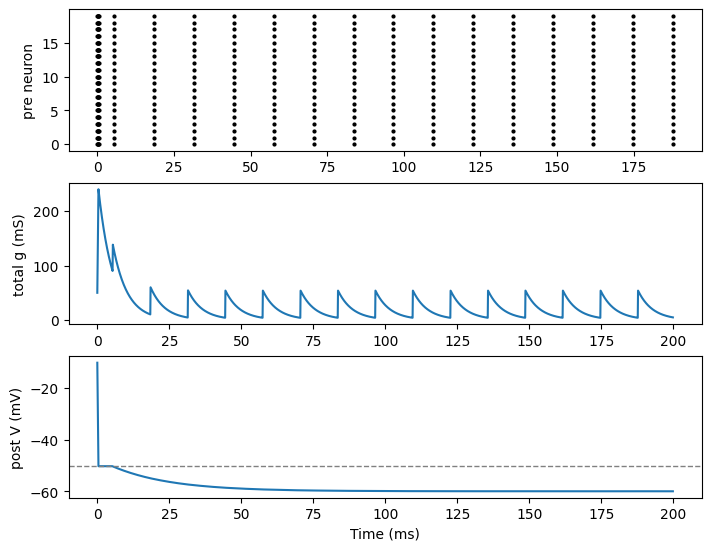

In [4]:
t_ms = times.to_decimal(u.ms)

fig, gs = braintools.visualize.get_figure(3, 1, 1.8, 7.0)

ax = fig.add_subplot(gs[0, 0])
ti, ni = u.math.where(pre_spk)
ax.scatter(t_ms[ti], ni, s=4, color='k')
ax.set_ylabel('pre neuron')

ax = fig.add_subplot(gs[1, 0])
ax.plot(t_ms, u.math.sum(syn_g, axis=1).to_decimal(u.mS))
ax.set_ylabel('total g (mS)')

ax = fig.add_subplot(gs[2, 0])
ax.plot(t_ms, post_V.to_decimal(u.mV)[:, 0])
ax.axhline(-50., ls='--', color='gray', lw=1)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('post V (mV)')
plt.show()

## See also

- :doc:`03-ei-balanced-network` — scale this up to an excitatory/inhibitory
  network.
- :doc:`/concepts/alignpre-alignpost` — the keystone: why state aligns to the
  postsynaptic side and when to use AlignPre instead.
- :doc:`../howto/sim-coba-cuba-synapses` — conductance- vs current-based outputs.
- :doc:`../howto/sim-delays` — add a transmission delay to a projection.